In [134]:
# ============================================
# Retail Sales Forecasting System
# Week 3 Internship Project
# ============================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Date Handling
from datetime import datetime

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [135]:
df = pd.read_csv("train.csv")
df.head(10)
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
df.info()
df.describe(include="all")

Rows : 9800
Columns : 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-nul

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [136]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Percentage
Row ID,0,0.00
Order ID,0,0.00
Order Date,0,0.00
Ship Date,0,0.00
Ship Mode,0,0.00
Customer ID,0,0.00
Customer Name,0,0.00
Segment,0,0.00
Country,0,0.00
City,0,0.00


In [137]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [138]:
df.drop_duplicates(inplace=True)

In [139]:
# Convert Order Date and Ship Date to datetime

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

In [140]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

In [141]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

In [142]:
df["Season"] = df["Month"].apply(get_season)

In [143]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,Monday,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,Tuesday,Autumn


In [144]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [145]:
print("Average Shipping Time:")

print(round(df["Shipping Days"].mean(),2),"days")

Average Shipping Time:
3.96 days


In [146]:
df.groupby("Region")["Shipping Days"].mean()

,Shipping Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


In [147]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

In [148]:
weekly_sales = (
    df.resample(
        "W",
        on="Order Date"
    )["Sales"]
    .sum()
    .reset_index()
)

In [149]:
monthly_sales = (
    df.resample(
        "M",
        on="Order Date"
    )["Sales"]
    .sum()
    .reset_index()
)

Which product generates the highest revenue

In [150]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


In [151]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


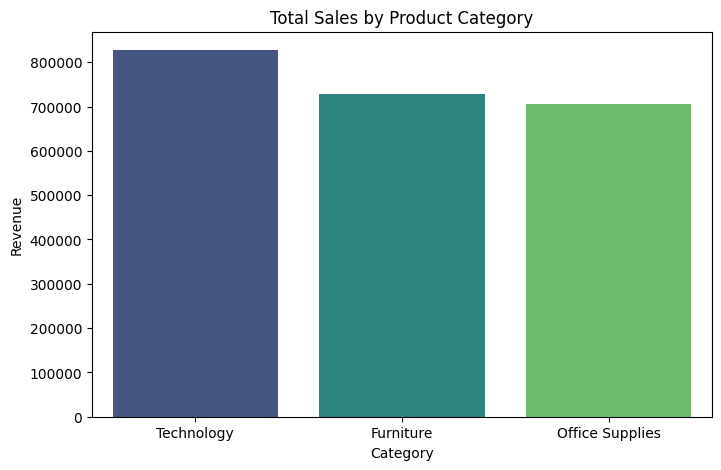

In [152]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

Average Shipping time

In [153]:
print("Average Shipping Time:")

round(df["Shipping Days"].mean(),2)
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_region

Average Shipping Time:


,Shipping Days
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


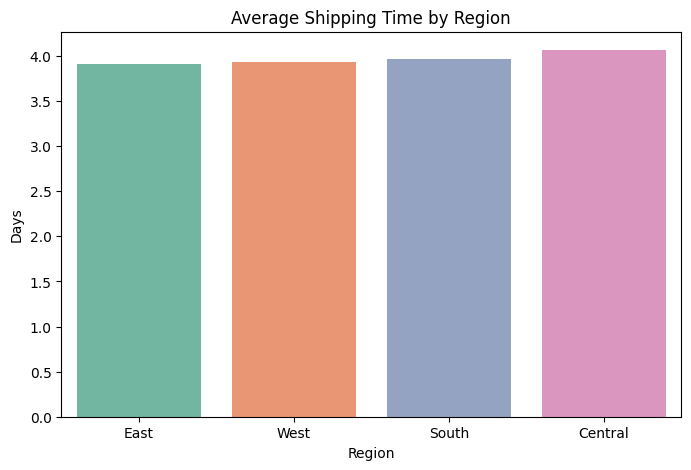

In [154]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    palette="Set2"
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Days")

plt.show()

Monthly sales trends

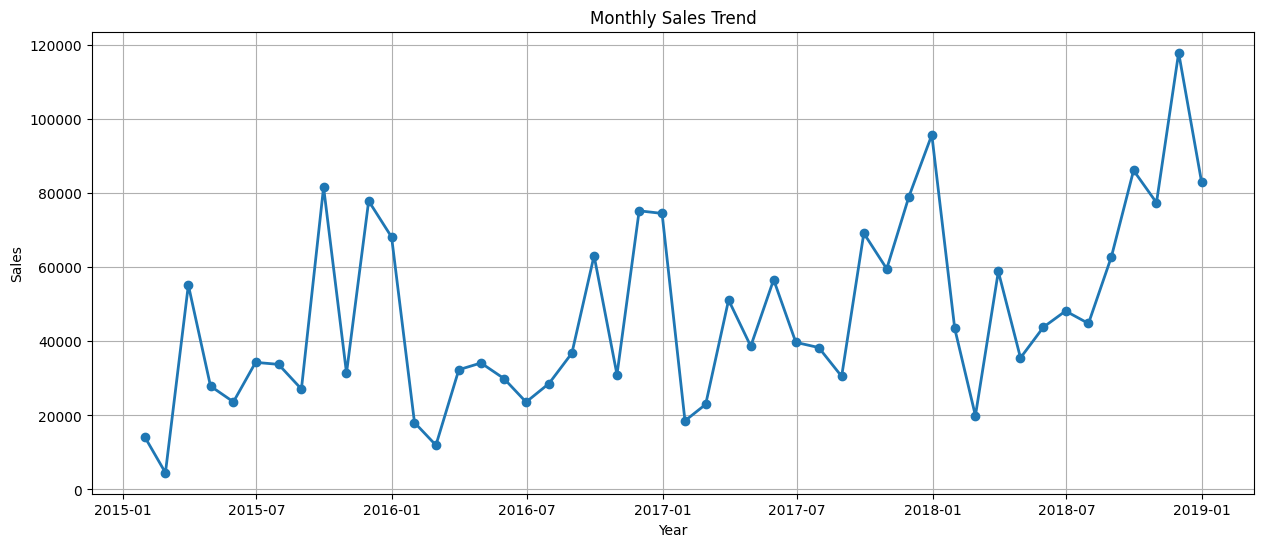

In [155]:
monthly_sales = (
    df.resample(
        "M",
        on="Order Date"
    )["Sales"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

Region shows the most consistent growth

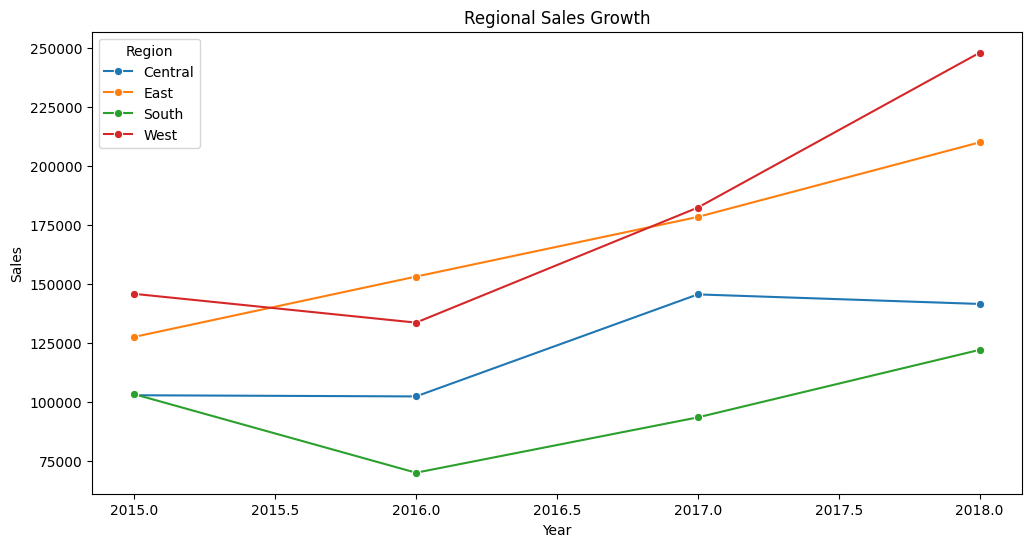

In [156]:
region_year_sales = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth")

plt.show()

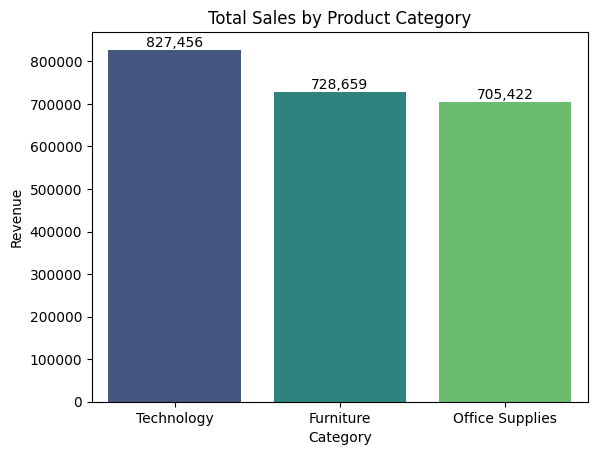

In [157]:
ax = sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

for i, value in enumerate(category_sales.values):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=10)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [158]:
# Monthly Sales Time Series

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .to_frame()
)

monthly_sales.head()
monthly_sales.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2015-01-31 to 2018-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes


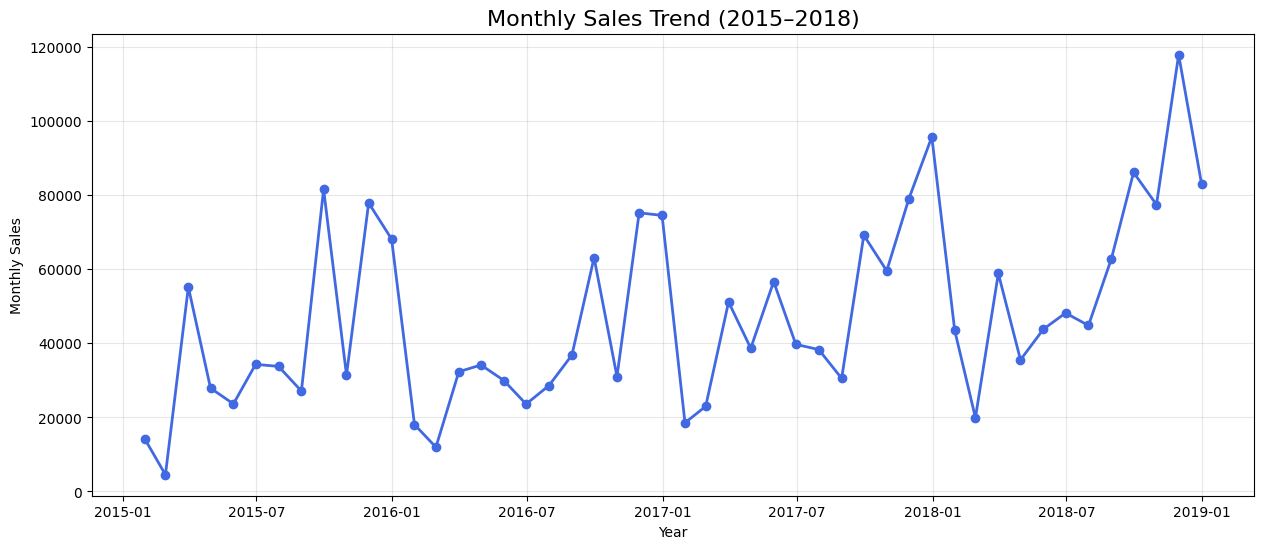

In [159]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    marker='o',
    linewidth=2,
    color='royalblue'
)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Monthly Sales")
plt.grid(alpha=0.3)

plt.show()

In [160]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [161]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

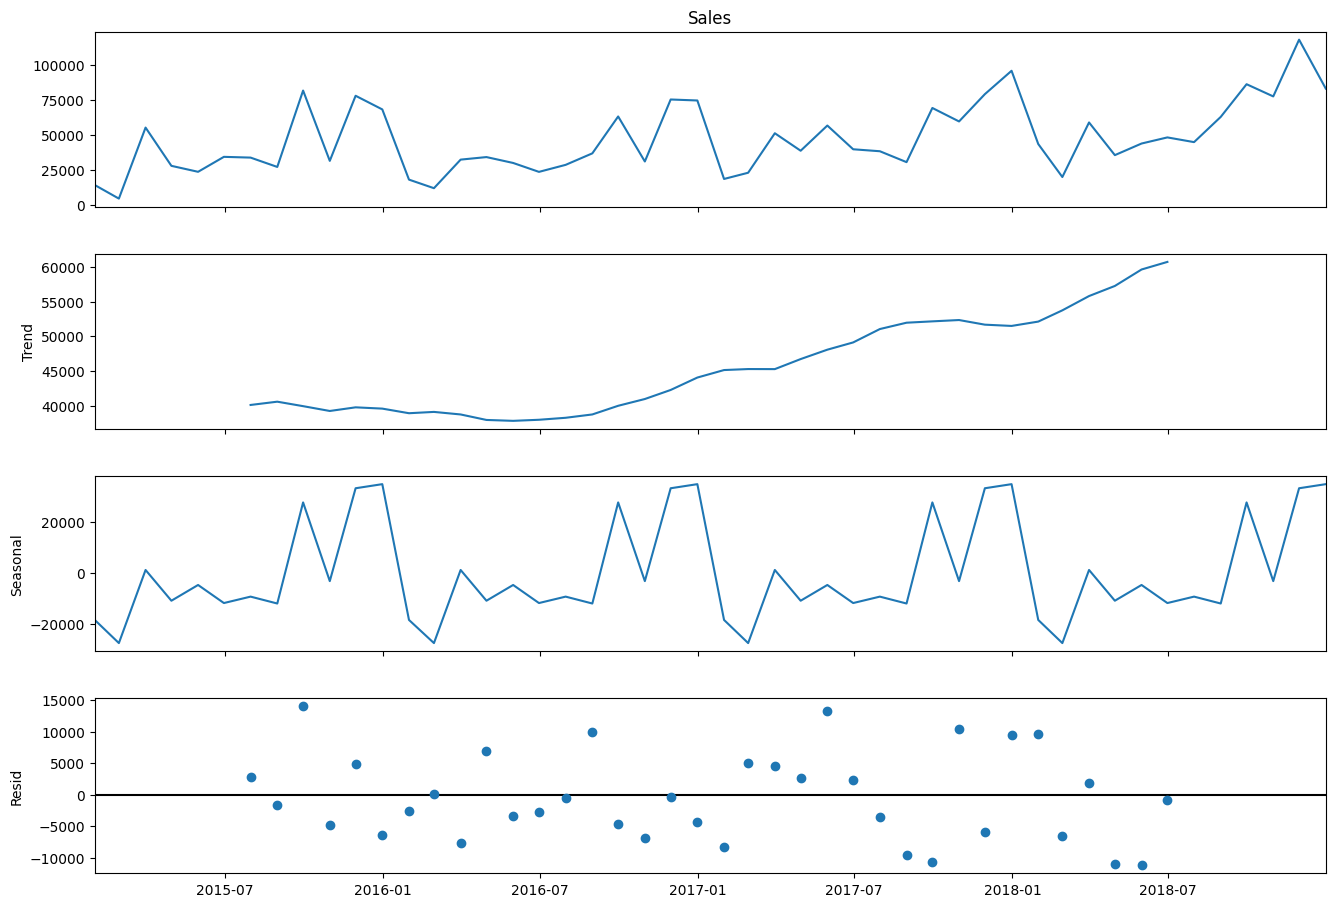

In [162]:
fig = decomposition.plot()
fig.set_size_inches(15,10)

plt.show()

Trend: Indicates the long-term movement in sales over time.

Seasonality: Shows recurring monthly sales patterns that repeat every year.

Residual: Represents random fluctuations that cannot be explained by trend or seasonality.

In [163]:
from statsmodels.tsa.stattools import adfuller

In [164]:
!pip install statsmodels

In [165]:
adf_result = adfuller(monthly_sales["Sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [166]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [167]:
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

In [168]:
print(train.tail())
print(test)

                 Sales
Order Date            
2018-05-31  43825.9822
2018-06-30  48190.7277
2018-07-31  44825.1040
2018-08-31  62837.8480
2018-09-30  86152.8880
                  Sales
Order Date             
2018-10-31   77448.1312
2018-11-30  117938.1550
2018-12-31   83030.3888


In [169]:
sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

In [170]:
forecast = sarima_fit.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

In [171]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [172]:
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

In [173]:
print(forecast_mean)

2018-10-31    60331.792101
2018-11-30    91458.220223
2018-12-31    97167.570951
Freq: ME, Name: predicted_mean, dtype: float64


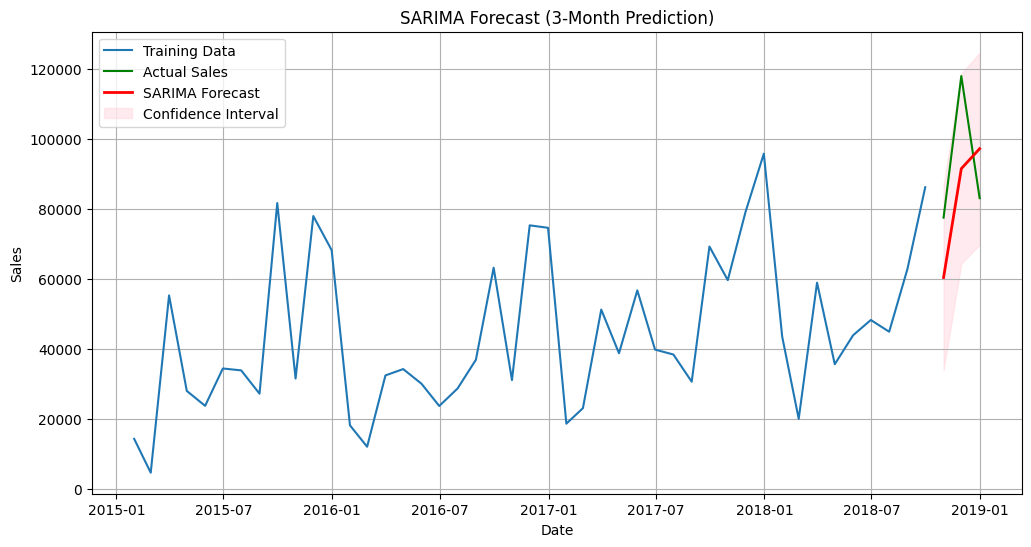

In [174]:
plt.figure(figsize=(12,6))

# Training Data
plt.plot(train.index,
         train["Sales"],
         label="Training Data")

# Actual Data
plt.plot(test.index,
         test["Sales"],
         label="Actual Sales",
         color="green")

# Forecast
plt.plot(test.index,
         forecast_mean,
         label="SARIMA Forecast",
         color="red",
         linewidth=2)

# Confidence Interval
plt.fill_between(
    test.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast (3-Month Prediction)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [175]:
mae_sarima = mean_absolute_error(
    test["Sales"],
    forecast_mean
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        test["Sales"],
        forecast_mean
    )
)

mape_sarima = np.mean(
    np.abs(
        (test["Sales"]-forecast_mean)
        /test["Sales"]
    )
)*100

print(f"MAE : {mae_sarima:.2f}")
print(f"RMSE : {rmse_sarima:.2f}")
print(f"MAPE : {mape_sarima:.2f}%")

MAE : 19244.49
RMSE : 19950.07
MAPE : 20.53%


In [176]:
print("Forecast Values")
print(forecast_mean)

Forecast Values
2018-10-31    60331.792101
2018-11-30    91458.220223
2018-12-31    97167.570951
Freq: ME, Name: predicted_mean, dtype: float64


In [177]:
mae_sarima = mean_absolute_error(test["Sales"], forecast_mean)

rmse_sarima = np.sqrt(
    mean_squared_error(test["Sales"], forecast_mean)
)

mape_sarima = np.mean(
    np.abs((test["Sales"]-forecast_mean)/test["Sales"])
)*100

print(f"MAE  : {mae_sarima:.2f}")
print(f"RMSE : {rmse_sarima:.2f}")
print(f"MAPE : {mape_sarima:.2f}%")

MAE  : 19244.49
RMSE : 19950.07
MAPE : 20.53%


Prophet Model

In [178]:
!pip install prophet

In [179]:
from prophet import Prophet

In [180]:
prophet_df = monthly_sales.reset_index()

prophet_df.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    },
    inplace=True
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [181]:
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]

In [182]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

In [183]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq='M'
)

In [184]:
forecast_prophet = prophet_model.predict(future)

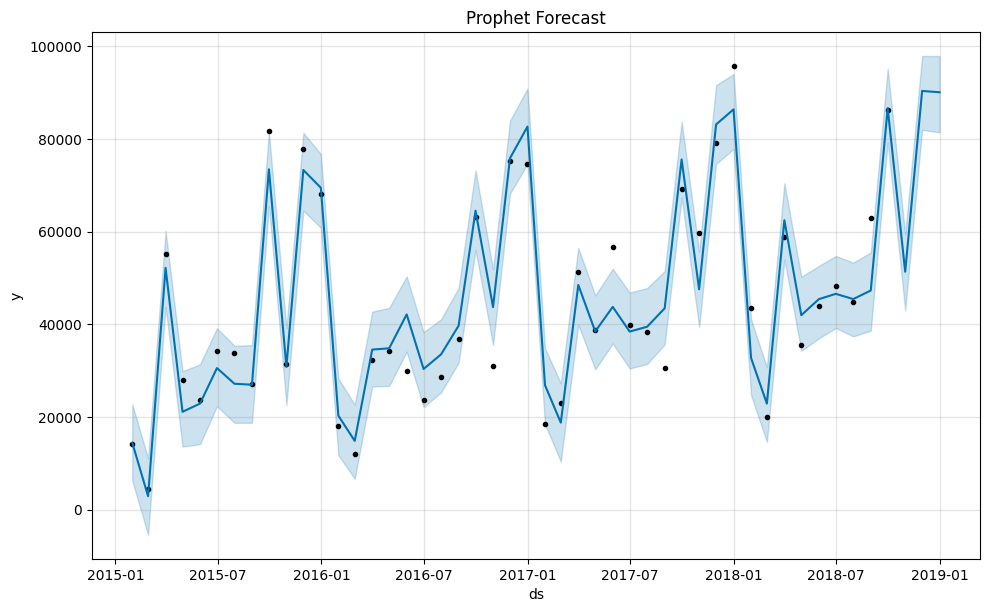

In [185]:
fig = prophet_model.plot(forecast_prophet)

plt.title("Prophet Forecast")

plt.show()

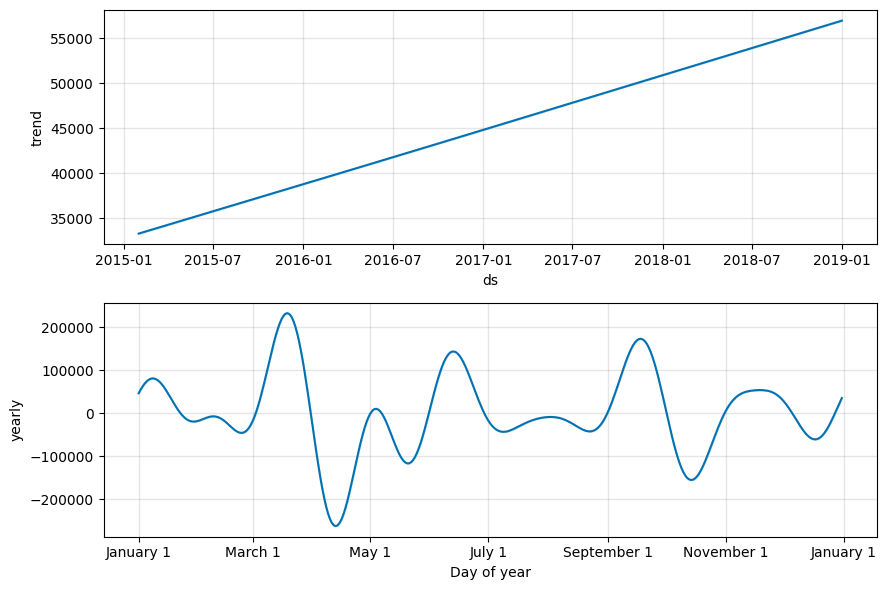

In [186]:
fig = prophet_model.plot_components(forecast_prophet)

plt.show()

In [187]:
predicted = forecast_prophet["yhat"].tail(3).values
actual = test_prophet["y"].values

In [188]:
mae_prophet = mean_absolute_error(actual, predicted)

rmse_prophet = np.sqrt(
    mean_squared_error(actual, predicted)
)

mape_prophet = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.2f}%")

MAE  : 20250.79
RMSE : 22318.41
MAPE : 21.86%


XGBoost

In [189]:
!pip install xgboost

In [190]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [191]:
xgb_df = monthly_sales.copy()

In [192]:
# Previous month's sales
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

# Two months ago
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

# Three months ago
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

In [193]:
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

In [194]:
xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter
xgb_df["Year"] = xgb_df.index.year

In [195]:
xgb_df.dropna(inplace=True)

In [196]:
xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Year
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


In [197]:
X = xgb_df.drop("Sales", axis=1)
y = xgb_df["Sales"]

In [198]:
split = len(X) - 3

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [199]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [200]:
xgb_prediction = xgb_model.predict(X_test)

In [201]:
mae_xgb = mean_absolute_error(y_test, xgb_prediction)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_prediction)
)

mape_xgb = np.mean(
    np.abs((y_test - xgb_prediction) / y_test)
) * 100

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

MAE  : 15110.78
RMSE : 19239.17
MAPE : 14.81%


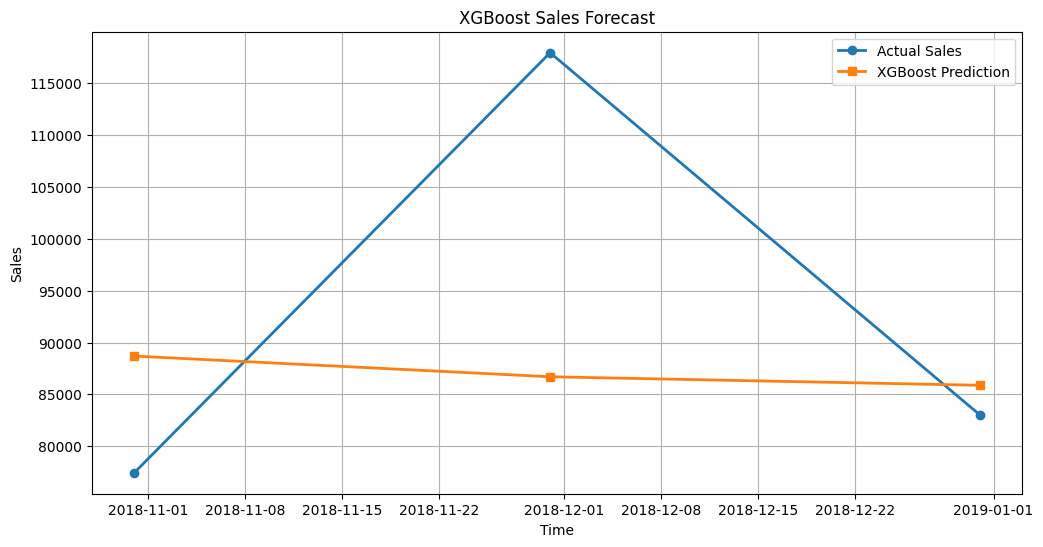

In [202]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test.values,
    marker='o',
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_test.index,
    xgb_prediction,
    marker='s',
    linewidth=2,
    label="XGBoost Prediction"
)

plt.title("XGBoost Sales Forecast")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [203]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Month,0.789484
6,Year,0.077380
3,Rolling_Mean_3,0.058855
1,Lag_2,0.031977
0,Lag_1,0.031822
2,Lag_3,0.010482
5,Quarter,0.000000


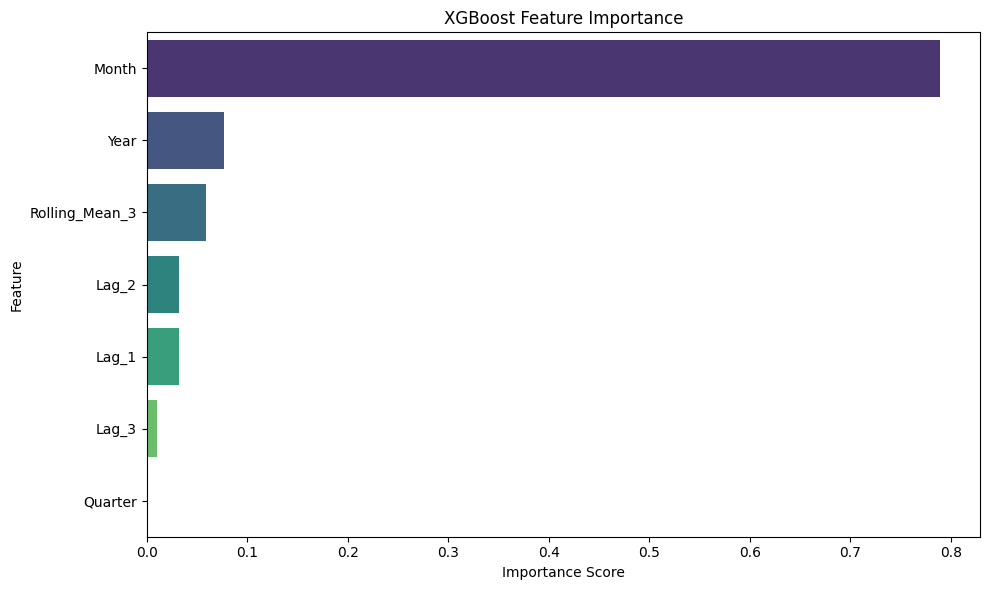

In [204]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [205]:
# Weekly Sales Aggregation

weekly_sales = (
    df.resample("W", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [206]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [207]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly_IF"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

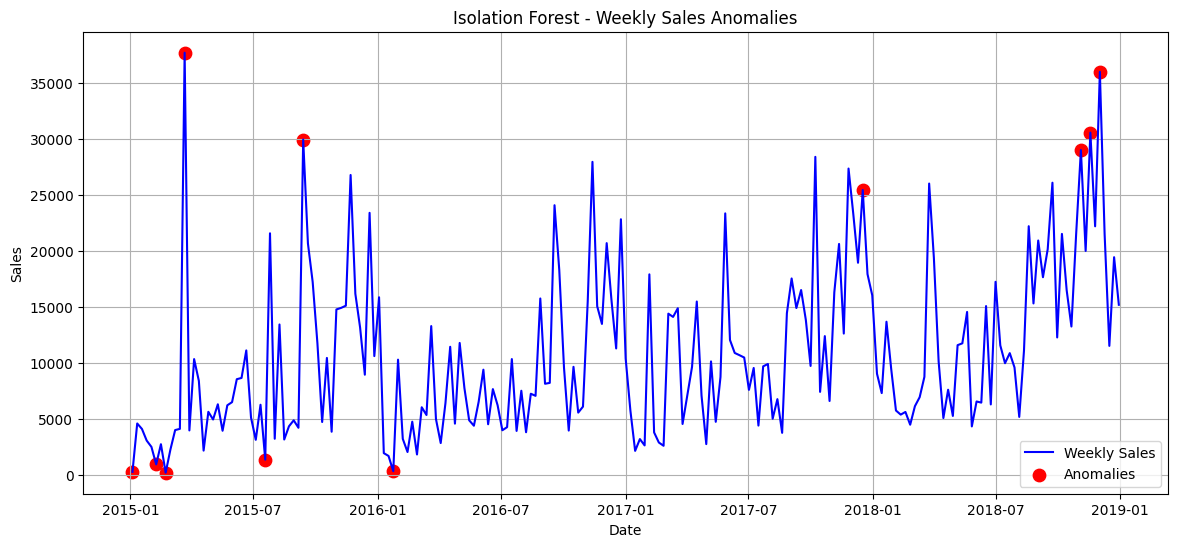

In [208]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly_IF"]==-1
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomalies"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [209]:
weekly_sales["ZScore"] = zscore(
    weekly_sales["Sales"]
)

weekly_sales["Anomaly_Z"] = np.where(
    abs(weekly_sales["ZScore"])>2,
    -1,
    1
)

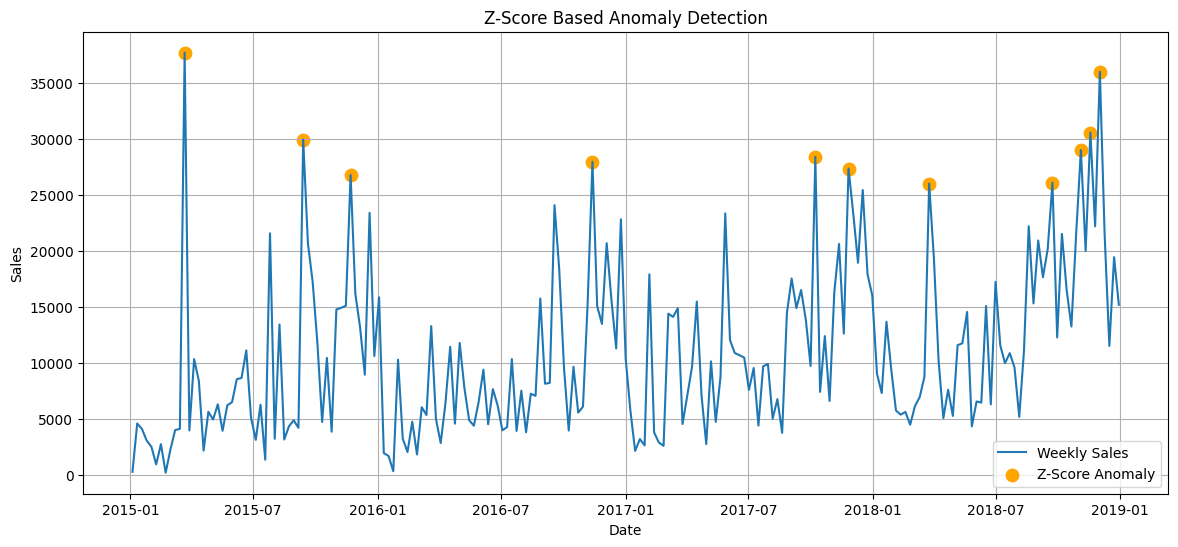

In [210]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_anomaly = weekly_sales[
    weekly_sales["Anomaly_Z"]==-1
]

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [211]:
comparison = weekly_sales[
    ["Order Date","Sales","Anomaly_IF","Anomaly_Z"]
]

comparison.head(20)

,Order Date,Sales,Anomaly_IF,Anomaly_Z
0,2015-01-04,304.508,-1,1
1,2015-01-11,4619.108,1,1
2,2015-01-18,4130.533,1,1
3,2015-01-25,3092.544,1,1
4,2015-02-01,2527.914,1,1
5,2015-02-08,968.534,-1,1
6,2015-02-15,2771.054,1,1
7,2015-02-22,224.912,-1,1
8,2015-03-01,2289.643,1,1
9,2015-03-08,4030.728,1,1


In [212]:
print("Isolation Forest Anomalies :")

print(
    (weekly_sales["Anomaly_IF"]==-1).sum()
)

print()

print("Z-Score Anomalies :")

print(
    (weekly_sales["Anomaly_Z"]==-1).sum()
)

Isolation Forest Anomalies :
11

Z-Score Anomalies :
11


In [213]:
product_data = df.groupby("Sub-Category").agg({
    "Sales":"sum"
})

product_data.head()

,Sales
Sub-Category,
Accessories,164186.7000
Appliances,104618.4030
Art,26705.4100
Binders,200028.7850
Bookcases,113813.1987


In [214]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [215]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(product_data)

In [216]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(product_data)

In [217]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

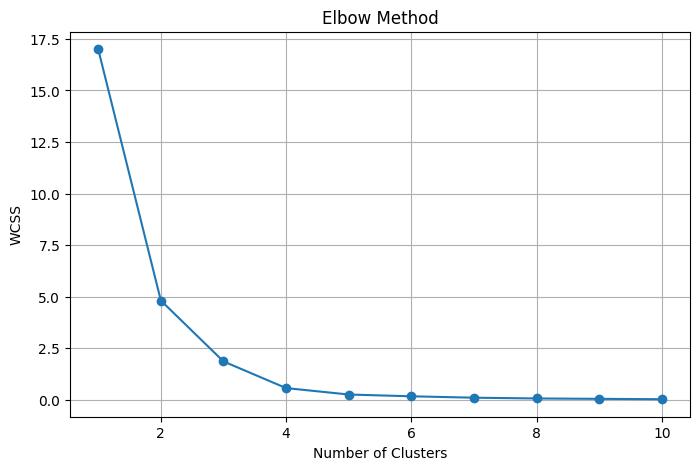

In [218]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [219]:
# Apply K-Means with optimal clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(scaled_data)

product_data.head()

,Sales,Cluster
Sub-Category,,
Accessories,164186.7000,0
Appliances,104618.4030,3
Art,26705.4100,1
Binders,200028.7850,0
Bookcases,113813.1987,3


In [220]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month Name', 'Quarter', 'Week', 'Day', 'Season', 'Shipping Days']


In [221]:
# Aggregate product-level features

product_data = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Average_Sales=("Sales", "mean"),
    Sales_STD=("Sales", "std"),
    Order_Count=("Sales", "count")
)

product_data = product_data.fillna(0)

product_data.head()

,Total_Sales,Average_Sales,Sales_STD,Order_Count
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,756
Appliances,104618.4030,227.926804,378.006735,459
Art,26705.4100,34.019631,60.301752,785
Binders,200028.7850,134.067550,568.099970,1492
Bookcases,113813.1987,503.598224,641.419280,226


In [222]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(product_data)

print(product_data.shape)
print(scaled_data.shape)

(17, 4)
(17, 4)


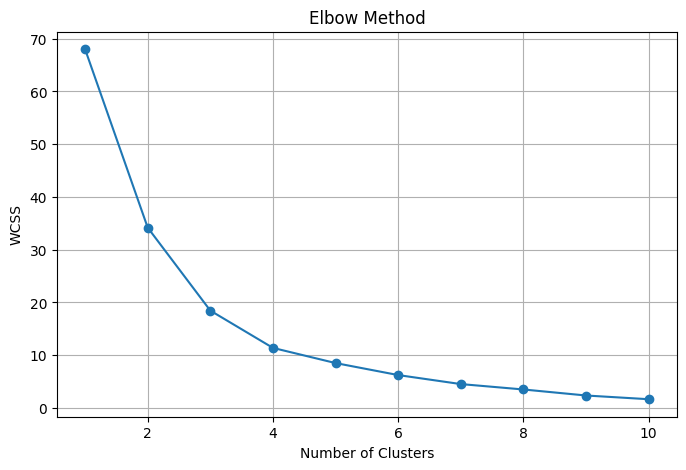

In [223]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [224]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(scaled_data)

product_data.head()

,Total_Sales,Average_Sales,Sales_STD,Order_Count,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,337.723800,756,1
Appliances,104618.4030,227.926804,378.006735,459,2
Art,26705.4100,34.019631,60.301752,785,1
Binders,200028.7850,134.067550,568.099970,1492,1
Bookcases,113813.1987,503.598224,641.419280,226,2


In [225]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = product_data["Cluster"].values

pca_df["Sub-Category"] = product_data.index

pca_df.head()

,PC1,PC2,Cluster,Sub-Category
0,-0.575071,0.464346,1,Accessories
1,-0.366890,-0.443146,2,Appliances
2,-1.271306,-0.643922,1,Art
3,-1.140130,1.821152,1,Binders
4,0.362766,-0.654069,2,Bookcases


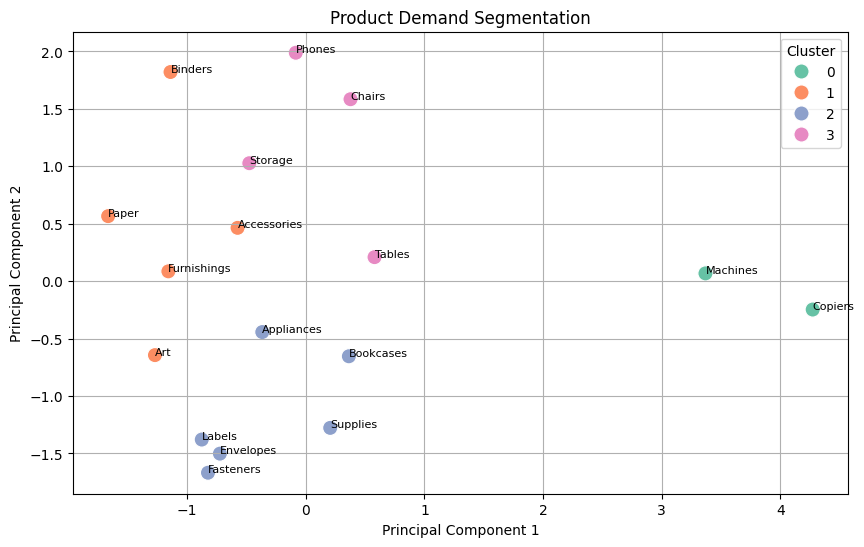

In [226]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=120
)

for i in range(len(pca_df)):
    plt.text(
        pca_df.iloc[i]["PC1"],
        pca_df.iloc[i]["PC2"],
        pca_df.iloc[i]["Sub-Category"],
        fontsize=8
    )

plt.title("Product Demand Segmentation")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [227]:
cluster_summary = product_data.groupby("Cluster").mean()

cluster_summary

,Total_Sales,Average_Sales,Sales_STD,Order_Count
Cluster,,,,
0,167743.362500,1930.716763,2990.643794,90.500000
1,111392.243400,107.701895,238.607860,1060.400000
2,49388.273617,182.909512,354.992338,281.333333
3,268189.799750,453.885411,499.765747,657.250000


In [228]:
for cluster in sorted(product_data["Cluster"].unique()):

    print(f"\nCluster {cluster}")
    print("-"*40)

    products = product_data[
        product_data["Cluster"] == cluster
    ].index.tolist()

    print(products)


Cluster 0
----------------------------------------
['Copiers', 'Machines']

Cluster 1
----------------------------------------
['Accessories', 'Art', 'Binders', 'Furnishings', 'Paper']

Cluster 2
----------------------------------------
['Appliances', 'Bookcases', 'Envelopes', 'Fasteners', 'Labels', 'Supplies']

Cluster 3
----------------------------------------
['Chairs', 'Phones', 'Storage', 'Tables']


**Product Demand Segmentation**

The Elbow Method indicated that four clusters provided a suitable balance between model simplicity and within-cluster variation. Product sub-categories were grouped using Total Sales, Average Sales, Sales Variability, and Number of Orders. PCA reduced these features into two principal components for visualization. The resulting clusters highlight products with similar demand characteristics, helping businesses optimize inventory planning, replenishment schedules, and promotional strategies.

**Executive Business Report**

**Executive Summary**

This project developed an end-to-end sales forecasting and inventory planning solution using historical retail sales data. The system analyzes sales trends, identifies seasonal patterns, forecasts future demand using multiple forecasting models, detects unusual sales behavior through anomaly detection, and segments products into demand-based clusters. Three forecasting techniques, namely SARIMA, Prophet, and XGBoost, were evaluated and compared using MAE, RMSE, and MAPE metrics. Based on the evaluation results, XGBoost achieved the lowest MAPE, making it the preferred model for production deployment. The overall solution provides actionable insights that support inventory optimization, demand planning, and strategic business decision-making.

Key Findings
Technology products generated the highest overall sales revenue.
Sales exhibited clear seasonal trends with recurring peak periods each year.
XGBoost delivered the most accurate demand forecasts based on the lowest MAPE, while Prophet captured long-term trends and seasonality effectively.
Anomaly detection identified several unusual sales spikes that may correspond to promotional campaigns, seasonal demand, or holiday shopping periods.
Product sub-categories were successfully grouped into four demand clusters using K-Means clustering, enabling more effective inventory planning.

**Three-Month Sales Forecast**

The forecasting models predict a continued positive sales trend over the next three months. Confidence intervals generated by the SARIMA model indicate expected variation in future demand, while XGBoost provides the most accurate point forecasts. These predictions can help the business prepare inventory, reduce stock shortages, and avoid unnecessary overstocking during upcoming sales periods.

**Product Demand Segmentation**

Products were grouped into four clusters based on their sales characteristics. High-demand clusters should receive priority during inventory replenishment, while low-demand products should be stocked conservatively. Seasonal products require flexible inventory strategies aligned with forecasted demand patterns. This segmentation enables better resource allocation and improves inventory efficiency.

Business Recommendations
Adopt the XGBoost forecasting model for monthly inventory planning due to its superior forecasting accuracy.
Increase inventory allocation for high-demand product clusters before expected seasonal sales peaks.
Continuously monitor anomaly reports to identify unexpected demand changes and respond quickly with pricing, marketing, or inventory adjustments.
Limitations

The forecasting system relies solely on historical sales data and does not consider external factors such as marketing campaigns, holidays, competitor activities, or broader economic conditions. Incorporating these variables in future versions could further improve forecast accuracy and business decision-making.

In [230]:
%who

IsolationForest	 KMeans	 PCA	 Prophet	 SARIMAX	 StandardScaler	 X	 XGBRegressor	 X_test	 
X_train	 actual	 adf_result	 adfuller	 anomalies	 ax	 category_sales	 cluster	 cluster_summary	 
comparison	 daily_sales	 datetime	 decomposition	 df	 duplicates	 fig	 forecast	 forecast_ci	 
forecast_mean	 forecast_prophet	 future	 get_season	 i	 importance	 iso	 key	 kmeans	 
load_data	 mae_prophet	 mae_sarima	 mae_xgb	 mape_prophet	 mape_sarima	 mape_xgb	 mean_absolute_error	 mean_squared_error	 
missing	 model	 monthly_sales	 np	 pca	 pca_data	 pca_df	 pd	 plt	 
predicted	 product_data	 products	 prophet_df	 prophet_model	 px	 region_year_sales	 rmse_prophet	 rmse_sarima	 
rmse_xgb	 sarima_fit	 sarima_model	 scaled_data	 scaler	 seasonal_decompose	 shipping_region	 sns	 split	 
st	 test	 test_prophet	 train	 train_prophet	 value	 warnings	 wcss	 weekly_sales	 
xgb_df	 xgb_model	 xgb_prediction	 y	 y_test	 y_train	 z_anomaly	 zscore	 


In [231]:
forecast_df = pd.DataFrame({
    "Actual": test["Sales"].values,
    "Predicted": xgb_prediction
})

forecast_df.to_csv("forecast.csv", index=False)

print("forecast.csv saved successfully!")

forecast.csv saved successfully!


In [232]:
monthly_sales.to_csv("monthly_sales.csv")

In [233]:
monthly_sales.to_csv("monthly_sales.csv")

In [234]:
weekly_sales.to_csv("anomalies.csv", index=False)

In [235]:
product_data.to_csv("clusters.csv")

In [ ]:
comparison.to_csv("comparison.csv", index=False)